# COMSOL Validation

This notebook serves to read in CSV files from $r_{eye}$, $t_{CBG}$, and $t_{SiO_2}$ parameter sweeps, plot the results, and calculate residuals and trends.

In [75]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

using CSV, DataFrames, Plots, Printf
gr(fmt = :png)

resultsdir = joinpath(@__DIR__, "results");

  Activating project at `~/BullseyeFDFD/BullseyeFDFD/validation`


## Comparison machinery

`load_pair()` reads the FDFD CSV and normalises the COMSOL export to matching column names/units. 

`compare()` overlays FDFD (line) vs COMSOL (markers).

`residuals()` and `tracking()` report percent differences and trend metrics.

**Same-mode mask:** metrics use only points where **both** solvers report the *same* mode.

In [76]:
QUANTS = [(:λ_nm, "λ (nm)"), (:Q, "Q"), (:V, "V (λ/n)³"),
          (:Fp, "Fp"), (:CF, "CF"), (:Ceff_NA, "Ceff_NA")]
LAMBDA_TOL = 3.0

function load_pair(param)
    fdfd  = CSV.read(joinpath(resultsdir, "fdfd_$param.csv"), DataFrame)
    cpath = joinpath(resultsdir, "comsol_$param.csv")
    (isfile(cpath) && countlines(cpath) > 1) || return fdfd, nothing
    c = CSV.read(cpath, DataFrame)
    rename!(c, names(c)[1] => "value")
    "λ_µm" in names(c) && (c[!, "λ_nm"]    = c[!, "λ_µm"] .* 1000)
    "Ceff" in names(c) && (c[!, "Ceff_NA"] = c[!, "Ceff"])
    return fdfd, c
end

function linterp(x, y, xq)
    map(xq) do q
        i = searchsortedlast(x, q)
        i == 0         && return y[1]
        i >= length(x) && return y[end]
        t = (q - x[i]) / (x[i+1] - x[i])
        (1 - t) * y[i] + t * y[i+1]
    end
end

function onbranch(fdfd, comsol)
    (hasproperty(fdfd, :λ_nm) && hasproperty(comsol, :λ_nm)) || return trues(nrow(comsol))
    fλ = linterp(fdfd.value, float.(fdfd.λ_nm), comsol.value)
    abs.(fλ .- float.(comsol.λ_nm)) .< LAMBDA_TOL
end

_mean(v) = sum(v) / length(v)
_std(v)  = (m = _mean(v); sqrt(sum(x -> (x - m)^2, v) / length(v)))
function _cor(a, b)
    ma, mb = _mean(a), _mean(b)
    sum((a .- ma) .* (b .- mb)) / sqrt(sum(x -> (x - ma)^2, a) * sum(x -> (x - mb)^2, b))
end

function compare(param, xlabel)
    fdfd, comsol = load_pair(param)
    mask = comsol === nothing ? nothing : onbranch(fdfd, comsol)
    quants = filter(q -> hasproperty(fdfd, q[1]), QUANTS)
    plts = map(quants) do (col, ylab)
        p = plot(fdfd.value, fdfd[!, col]; label="FDFD", marker=:circle, ms=3, lw=1.5,
                 xlabel, ylabel=ylab, title=ylab, legend=:best,
                 left_margin=5Plots.mm, bottom_margin=5Plots.mm)
        if comsol !== nothing && hasproperty(comsol, col)
            on, off = mask, .!mask
            any(on)  && scatter!(p, comsol.value[on],  comsol[!, col][on];
                                 label="COMSOL", marker=:x, ms=6, mc=:red)
            any(off) && scatter!(p, comsol.value[off], comsol[!, col][off];
                                 label="COMSOL (off-branch)", marker=:x, ms=5, mc=:gray)
        end
        p
    end
    plot(plts...; layout=(cld(length(plts), 3), 3), size=(1200, 350*cld(length(plts), 3)),
         plot_title="Sweep: $param")
end

function residuals(param)
    fdfd, comsol = load_pair(param)
    comsol === nothing && (println("— no COMSOL data for $param yet —"); return)
    mask = onbranch(fdfd, comsol)
    count(mask) == 0 && (println("— no on-branch overlap for $param —"); return)
    @printf("── residuals: %s (COMSOL vs FDFD, %d/%d same-mode pts) ──\n",
            param, count(mask), length(mask))
    for (col, ylab) in QUANTS
        (hasproperty(fdfd, col) && hasproperty(comsol, col)) || continue
        fq  = linterp(fdfd.value, float.(fdfd[!, col]), comsol.value)[mask]
        cv  = float.(comsol[!, col])[mask]
        rel = 100 .* (cv .- fq) ./ fq
        @printf("  %-10s  max|Δ%%|=%.2f   mean|Δ%%|=%.2f\n",
                ylab, maximum(abs, rel), sum(abs, rel)/length(rel))
    end
end

function tracking(param)
    fdfd, comsol = load_pair(param)
    comsol === nothing && (println("— no COMSOL data for $param yet —"); return)
    mask = onbranch(fdfd, comsol)
    count(mask) == 0 && (println("— no on-branch overlap for $param —"); return)
    xv = comsol.value[mask]
    @printf("── tracking: %s (FDFD vs COMSOL, %d same-mode pts) ──\n", param, count(mask))
    @printf("  %-10s %7s   %-16s %8s %8s\n", "", "r", "FDFD/COMSOL", "peak@F", "peak@C")
    for (col, ylab) in QUANTS
        (hasproperty(fdfd, col) && hasproperty(comsol, col)) || continue
        fq = linterp(fdfd.value, float.(fdfd[!, col]), comsol.value)[mask]
        cv = float.(comsol[!, col])[mask]
        ratio = fq ./ cv
        pF, pC = xv[argmax(fq)], xv[argmax(cv)]
        @printf("  %-10s %7.4f   %.4f ± %.4f %8.3f %8.3f\n",
                ylab, _cor(fq, cv), _mean(ratio), _std(ratio), pF, pC)
    end
end;

## 1. Eye radius (`rEye`)

Central disk of the Bullseye cavity.

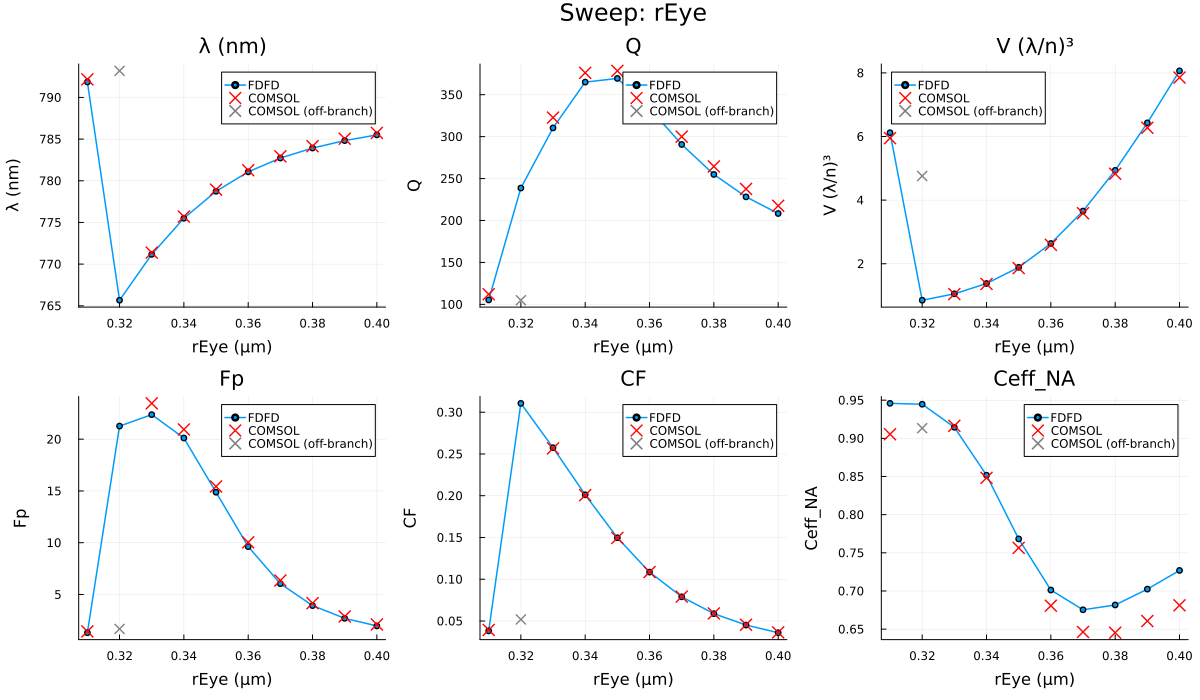

── residuals: rEye (COMSOL vs FDFD, 9/10 same-mode pts) ──
  λ (nm)      max|Δ%|=0.04   mean|Δ%|=0.03
  Q           max|Δ%|=6.49   mean|Δ%|=3.79
  V (λ/n)³    max|Δ%|=2.81   mean|Δ%|=1.84
  Fp          max|Δ%|=9.57   mean|Δ%|=5.74
  CF          max|Δ%|=2.95   mean|Δ%|=0.72
  Ceff_NA     max|Δ%|=6.29   mean|Δ%|=3.47
── tracking: rEye (FDFD vs COMSOL, 9 same-mode pts) ──
                   r   FDFD/COMSOL        peak@F   peak@C
  λ (nm)      1.0000   0.9997 ± 0.0000    0.310    0.310
  Q           0.9999   0.9636 ± 0.0105    0.350    0.350
  V (λ/n)³    1.0000   1.0187 ± 0.0069    0.400    0.400
  Fp          1.0000   0.9460 ± 0.0155    0.330    0.330
  CF          1.0000   0.9945 ± 0.0093    0.330    0.330
  Ceff_NA     0.9897   1.0360 ± 0.0240    0.310    0.330


In [77]:
display(compare(:rEye, "rEye (μm)"))
residuals(:rEye)
tracking(:rEye)

## 2. Cavity thickness (`tCBG`)

Thickness of the Bullseye cavity

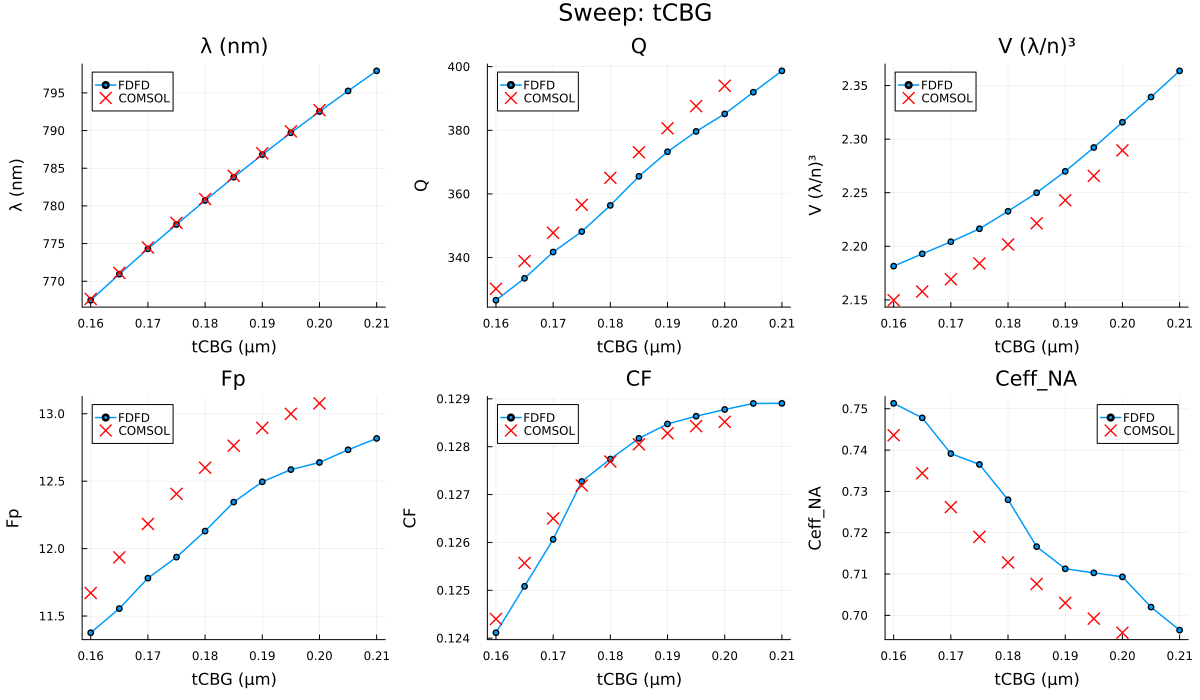

── residuals: tCBG (COMSOL vs FDFD, 9/9 same-mode pts) ──
  λ (nm)      max|Δ%|=0.03   mean|Δ%|=0.02
  Q           max|Δ%|=2.43   mean|Δ%|=1.98
  V (λ/n)³    max|Δ%|=1.61   mean|Δ%|=1.36
  Fp          max|Δ%|=3.93   mean|Δ%|=3.38
  CF          max|Δ%|=0.39   mean|Δ%|=0.19
  Ceff_NA     max|Δ%|=2.38   mean|Δ%|=1.66
── tracking: tCBG (FDFD vs COMSOL, 9 same-mode pts) ──
                   r   FDFD/COMSOL        peak@F   peak@C
  λ (nm)      1.0000   0.9998 ± 0.0000    0.200    0.200
  Q           0.9988   0.9806 ± 0.0039    0.200    0.200
  V (λ/n)³    0.9995   1.0138 ± 0.0018    0.200    0.200
  Fp          0.9960   0.9673 ± 0.0035    0.200    0.200
  CF          0.9960   0.9997 ± 0.0022    0.200    0.200
  Ceff_NA     0.9799   1.0169 ± 0.0044    0.160    0.160


In [78]:
display(compare(:tCBG, "tCBG (μm)"))
residuals(:tCBG)
tracking(:tCBG)

## 3. Substrate thickness (`tSiO2`)

Thickness of the substrate material.

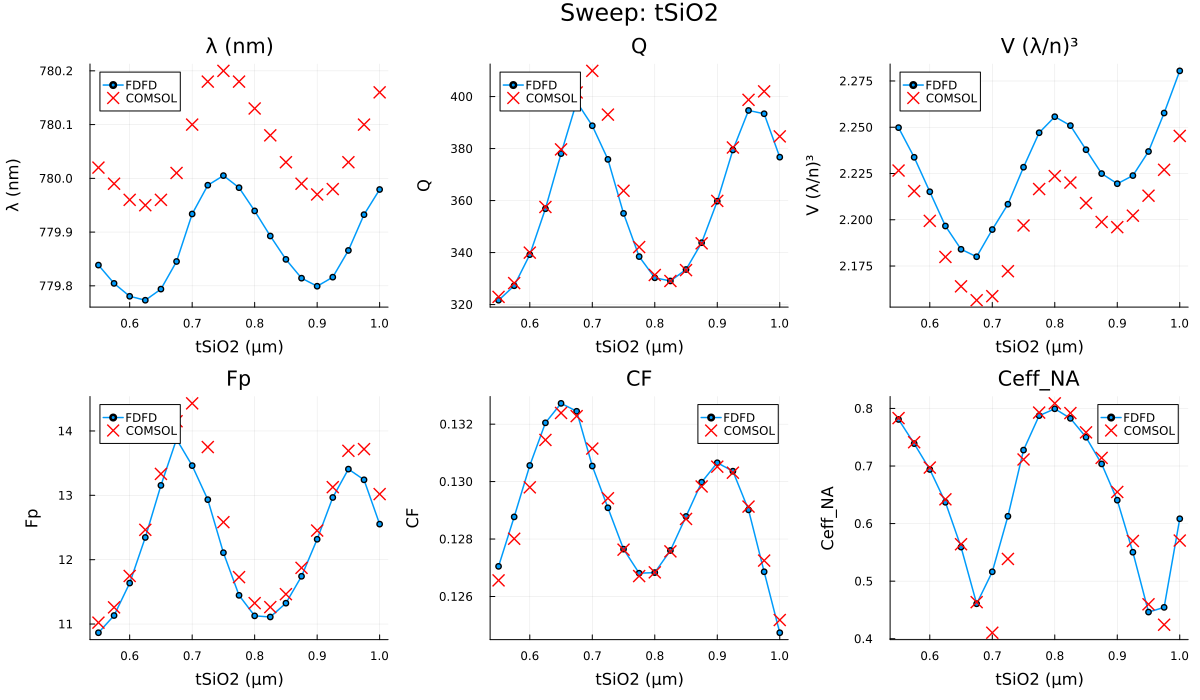

── residuals: tSiO2 (COMSOL vs FDFD, 19/19 same-mode pts) ──
  λ (nm)      max|Δ%|=0.03   mean|Δ%|=0.02
  Q           max|Δ%|=5.43   mean|Δ%|=1.16
  V (λ/n)³    max|Δ%|=1.64   mean|Δ%|=1.19
  Fp          max|Δ%|=7.19   mean|Δ%|=2.37
  CF          max|Δ%|=0.59   mean|Δ%|=0.23
  Ceff_NA     max|Δ%|=20.50   mean|Δ%|=3.45
── tracking: tSiO2 (FDFD vs COMSOL, 19 same-mode pts) ──
                   r   FDFD/COMSOL        peak@F   peak@C
  λ (nm)      0.9937   0.9998 ± 0.0000    0.750    0.750
  Q           0.9848   0.9889 ± 0.0146    0.675    0.700
  V (λ/n)³    0.9712   1.0121 ± 0.0029    1.000    1.000
  Fp          0.9813   0.9771 ± 0.0164    0.675    0.700
  CF          0.9851   1.0007 ± 0.0029    0.650    0.650
  Ceff_NA     0.9725   1.0200 ± 0.0693    0.800    0.800


In [79]:
display(compare(:tSiO2, "tSiO2 (μm)"))
residuals(:tSiO2)
tracking(:tSiO2)